In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/naghamalshbrawi/refined-bayyin-dataset/Refined_Bayyin_Dataset.csv


In [26]:
import torch
print("="*50)
print("GPU CHECK")
print("="*50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
    print("Go to Settings → Accelerator → Select 'GPU T4 x2'")
print("="*50)

GPU CHECK
CUDA available: True
Device count: 1
Current device: 0
Device name: Tesla P100-PCIE-16GB
CUDA version: 12.6


In [27]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

In [28]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset, load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score, 
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [29]:
MODEL_NAME = "ahmedabdelali/bert-base-qarib"
path = "/kaggle/input/datasets/naghamalshbrawi/refined-bayyin-dataset/Refined_Bayyin_Dataset.csv"

# Output directories 
OUTPUT_DIR_D3TOK = "/kaggle/working/runs/qarib_D3Tok"
SAVE_DIR_D3TOK = "/kaggle/working/qarib_D3Tok"

In [30]:
# Training parameters
TEXT_COL = "Word"
LABEL_COL = "Readability_Level"
LEVELS = [1, 2, 3, 4, 5, 6]
LR = 5e-5
BATCH = 64
EPOCHS = 6
MAX_LEN = 128
SEED = 42

## Data Preparation

In [31]:
print("\nLoading dataset...")
dataset = load_dataset("csv", data_files={"train": path}, split="train")
print(f"Dataset columns: {dataset.column_names}")
print(f"Dataset size: {len(dataset)}")


Loading dataset...
Dataset columns: ['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class', 'Dataset_Source']
Dataset size: 44917


In [32]:
required_column = ["D3Tok", LABEL_COL]
missing = [col for col in required_column if col not in dataset.column_names]
if missing:
    print(f"Missing columns: {missing}")

In [33]:
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)
splits = DatasetDict({
    "train": train_test["train"],
    "test": test_valid["train"],
    "validation": test_valid["test"],
})
print(f"Train: {len(splits['train'])}, Test: {len(splits['test'])}, Val: {len(splits['validation'])}")

Train: 31441, Test: 8984, Val: 4492


In [34]:
level2id = {lvl: i for i, lvl in enumerate(LEVELS)}
id2level = {i: lvl for lvl, i in level2id.items()}

def map_labels(ds):
    return ds.map(lambda ex: {"labels": level2id[int(ex[LABEL_COL])]})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Model Training

In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    return {"accuracy": acc, "macro_f1": macro_f1, "qwk": qwk}

In [36]:
class OrdinalAwareTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        probs = torch.softmax(logits, dim=-1)

        # =========================
        # 1️⃣ HARD EXAMPLE WEIGHTING
        # =========================
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze()

        # Hard sample → low confidence → high weight
        difficulty_weight = 1.0 - true_probs.detach()

        # Stabilize
        difficulty_weight = difficulty_weight + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # =========================
        # 2️⃣ ORDINAL DISTANCE PENALTY
        # =========================
        K = logits.shape[-1]
        indices = torch.arange(K).float().to(logits.device)

        labels_float = labels.float().unsqueeze(1)
        dist = torch.abs(indices - labels_float)

        distance_penalty = torch.exp(-dist / 2.0)
        distance_penalty = distance_penalty / distance_penalty.sum(dim=1, keepdim=True)

        # =========================
        # BASE LOSS (Cross Entropy)
        # =========================
        ce_loss = F.cross_entropy(logits, labels, reduction="none")

        # =========================
        # APPLY WEIGHTS
        # =========================
        weighted_loss = ce_loss * difficulty_weight

        # Optional small ordinal regularization
        log_probs = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, distance_penalty, reduction="none").sum(dim=1)

        final_loss = (weighted_loss + 0.3 * ordinal_loss).mean()

        return (final_loss, outputs) if return_outputs else final_loss

In [37]:
def eval_and_report(ds, name, trainer_obj):
    out = trainer_obj.predict(ds)
    preds = out.predictions.argmax(-1)
    print(f"\n{'='*60}")
    print(f"{name} Metrics")
    print('='*60)
    print(out.metrics)
    y_true = ds["labels"]
    target_names = [f"L{lvl}" for lvl in LEVELS]
    print("\nPer-class F1:")
    print(classification_report(y_true, preds, target_names=target_names, digits=4))

In [38]:
def plot_confusion_matrix_normalized(ds, trainer_obj, title_suffix="", normalize='true', cmap='Blues'):
    preds_output = trainer_obj.predict(ds)
    y_true = ds["labels"]
    y_pred = preds_output.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"L{lvl}" for lvl in LEVELS])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.show()

In [39]:
def train_model(text_col, output_dir, save_dir, model_name="Model"):
    print(f"\n{'#'*60}")
    print(f"# TRAINING MODEL: {model_name}")
    print(f"# Text Column: {text_col}")
    print(f"{'#'*60}\n")

    def tokenize_fn(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=MAX_LEN)

    train_ds = map_labels(splits["train"]).map(tokenize_fn, batched=True)
    val_ds = map_labels(splits["validation"]).map(tokenize_fn, batched=True)
    test_ds = map_labels(splits["test"]).map(tokenize_fn, batched=True)

    cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    print(f"Loading model: {MODEL_NAME}")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LEVELS))

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        seed=SEED,report_to="none",
        save_total_limit=3,
        save_safetensors=False,
        fp16=torch.cuda.is_available(),
    )

    trainer = OrdinalAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    print(f"Starting Training for Qarib for {EPOCHS} epochs...")
    trainer.train()

    print(f"\nSaving fine-tuned model to: {save_dir}")
    trainer.model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(" Model and tokenizer saved successfully!")

    print("\nEvaluating on Test Set...")
    eval_and_report(test_ds, f"Test (Qarib + SOFT - {model_name})", trainer)
    plot_confusion_matrix_normalized(test_ds, trainer, title_suffix=model_name)

    return trainer, test_ds

STARTING TRAINING PIPELINE FOR  - Qarib

############################################################
# TRAINING MODEL: D3Tok
# Text Column: D3Tok
############################################################



Map:   0%|          | 0/4492 [00:00<?, ? examples/s]

Loading model: ahmedabdelali/bert-base-qarib


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ahmedabdelali/bert-base-qarib and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Training for Qarib for 6 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk
1,1.209100,1.014865,0.770036,0.766265,0.856556
2,0.880400,0.972436,0.787400,0.785822,0.870381
3,0.663800,1.108360,0.786064,0.784737,0.879202
4,0.508000,1.234149,0.778495,0.777605,0.866995
5,0.424200,1.338224,0.780499,0.779727,0.869547
6,0.384200,1.376094,0.787400,0.785887,0.875817



Saving fine-tuned model to: /kaggle/working/qarib_D3Tok
 Model and tokenizer saved successfully!

Evaluating on Test Set...



Test (Qarib + SOFT - D3Tok) Metrics
{'test_loss': 1.1188595294952393, 'test_accuracy': 0.7823909171861086, 'test_macro_f1': 0.7802773415671179, 'test_qwk': 0.8778509464851182, 'test_runtime': 31.7403, 'test_samples_per_second': 283.047, 'test_steps_per_second': 4.442}

Per-class F1:
              precision    recall  f1-score   support

          L1     0.7658    0.7986    0.7818      1519
          L2     0.7514    0.7199    0.7353      1528
          L3     0.7216    0.7967    0.7573      1353
          L4     0.6596    0.6541    0.6569      1437
          L5     0.8420    0.9229    0.8806      1530
          L6     0.9597    0.7953    0.8698      1617

    accuracy                         0.7824      8984
   macro avg     0.7833    0.7813    0.7803      8984
weighted avg     0.7876    0.7824    0.7829      8984



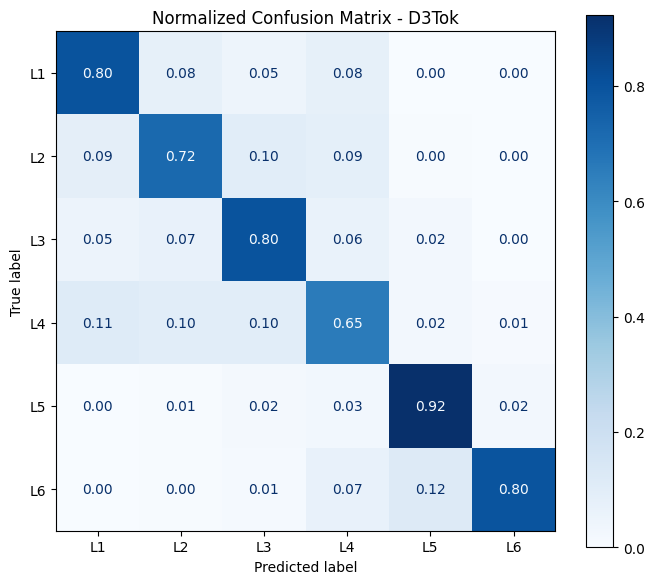


── D3Tok ──
  eval_loss: 1.1189
  eval_accuracy: 0.7824
  eval_macro_f1: 0.7803
  eval_qwk: 0.8779
  eval_runtime: 31.6864
  eval_samples_per_second: 283.5280
  eval_steps_per_second: 4.4500
  epoch: 6.0000


In [40]:
if __name__ == "__main__":
    results = {}
    print("STARTING TRAINING PIPELINE FOR  - Qarib")

    # Train D3Tok
    trainer_d3tok, test_ds_d3tok = train_model("D3Tok", OUTPUT_DIR_D3TOK, SAVE_DIR_D3TOK, "D3Tok")
    results["D3Tok"] = trainer_d3tok.evaluate(test_ds_d3tok)

for model_name, metrics in results.items():
    print(f"\n── {model_name} ──")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")